# Tutorial 01: Electronic Structure

In this tutorial you will run the complete PAOFLOW post-processing workflow on bulk silicon: build a PAO Hamiltonian from atomic projections, interpolate the electronic band structure, compute the density of states, and evaluate Boltzmann transport tensors.

**What you will learn**

- How Kohn–Sham wavefunctions are projected onto pseudo-atomic orbital (PAO) bases
- How a real-space PAO Hamiltonian $H(\mathbf{R})$ is built by Fourier transform
- How interpolation produces smooth bands on arbitrarily dense k-grids
- How the density of states and transport tensors are computed from interpolated eigenvalues


## Required Input

> This notebook assumes that a Quantum ESPRESSO `.save` directory is already available. Users may generate it themselves or download the tutorial assets from the [PAOFLOW Releases page](https://github.com/marcobn/PAOFLOW/releases).

The `.save` directory must contain:

- `data-file-schema.xml` — crystal structure, k-point grid, and Kohn–Sham eigenvalues
- `atomic_proj.xml` — projection amplitudes and overlap matrices



## 1. Initialise PAOFLOW

`PAOFLOW.PAOFLOW(...)` reads `data-file-schema.xml` to load the crystal structure, k-point grid, and Kohn–Sham eigenvalues, then prepares all internal data structures. All output files are written to `outputdir`.


In [16]:
# Adjust these paths if needed
savedir = '../../examples/qe_examples/example01/silicon.save'  # Path to the QE save directory
outputdir = 'output'  # Path to the output directory for PAOFLOW results

In [ ]:
from PAOFLOW import PAOFLOW

paoflow = PAOFLOW.PAOFLOW(
    savedir=savedir,
    outputdir=outputdir,
    smearing='gauss',
    npool=1,
    verbose=True,
)


────────────────────────────────────────────────────────────────────────────────────
   PPPPPP\   AA\AAAAA\   OOOOOO\  FFFFFFFF\ LLL\        OOOOOO\  WW\   WW\   WW\ 
   PP  __PP\ AA  __AA\  OO  __OO\ FF  ____/ L  |       OO  __OO\ W  |  W  |  W  |
   PP /  P  |AA /  AA | OO /  OO |FF /      L  |       OO /  OO |W  |  W  |  W  |
   PPPPPPP  |AAAAAAAA | OO |  OO |FFFFFF    L  |       OO |  OO |W  |  W  |  W  |
   PP  ____/ AA  __AA | OO |  OO |FF  _/    L  |       OO |  OO |W |  W |  W | 
   PP /      AA /  AA | OO \__OO |FF /      L  |       OO \__OO |W |  W |  W | 
   PP/       AA/   AA |  \OOOOO   |FF/       LLLLLLLL\  \OOOOO   |\WWWWWWWWWW /  
   \__|      \__|  \__|   \______/ \__|      \________|  \______/  \_________/   
────────────────────────────────────────────────────────────────────────────────────
   From DFT wavefunctions to materials properties via atomic-orbital Hamiltonians   
────────────────────────────────────────────────────────────────────────────────────

Monkho

## 2. Read Atomic Projections

PAOFLOW represents the electronic structure in a **pseudo-atomic orbital (PAO)** basis — localised functions $|\phi_\alpha\rangle$ derived from the isolated-atom Kohn–Sham solutions for each angular momentum channel in the pseudopotential. For silicon ($3s^2\,3p^2$ valence configuration), this gives one $s$ and three $p$ orbitals per atom: eight PAOs for the two-atom unit cell.

The projection amplitudes

$$A_{n\alpha}(\mathbf{k}) = \langle\phi_\alpha|\psi_{n\mathbf{k}}\rangle$$

quantify how much of Kohn–Sham band $n$ at k-point $\mathbf{k}$ is captured by PAO $\alpha$. The overlap matrix $S_{\alpha\beta}(\mathbf{k})$ between PAOs on different sites is needed for the subsequent Löwdin orthogonalisation.


In [3]:
paoflow.read_atomic_proj_QE()

## 3. Check Projectability

The **projectability** of band $n$ at k-point $\mathbf{k}$,

$$p_{n\mathbf{k}} = \sum_\alpha |A_{n\alpha}(\mathbf{k})|^2,$$

measures how completely the PAO basis captures that band. Values near 1 indicate a good representation; values well below 1 correspond to high-energy, plane-wave-like states not captured by localised orbitals.

Bands with $p_{n\mathbf{k}}$ below the threshold (default 0.95) are excluded from Hamiltonian construction. For silicon, the four valence bands and four lowest conduction bands are well within the PAO window.


In [4]:
paoflow.projectability()

Projectability vector: 
 [0.99750288 0.99744382 0.99756619 0.99738312 0.9854761  0.97871706
 0.98197092 0.96888834 0.9401672  0.95578579 0.86801137 0.81708586
 0.77051565 0.68422827 0.47457293 0.46360893 0.41947435 0.36018918]
# of bands with good projectability > 0.95 = 9
Range of suggested shift  7.160617560055067  ,  10.893382916432914
Projectability in:                         13.316 sec


## 4. Build the PAO Hamiltonian

With the projection amplitudes in hand, the k-space PAO Hamiltonian is assembled as

$$\tilde{H}_{\alpha\beta}(\mathbf{k}) = \sum_n A^*_{n\alpha}(\mathbf{k})\,\varepsilon_{n\mathbf{k}}\,A_{n\beta}(\mathbf{k})$$

after Löwdin orthogonalisation of the PAO basis using $S(\mathbf{k})$. A discrete Fourier transform then maps this to real space:

$$H_{\alpha\beta}(\mathbf{R}) = \frac{1}{N_k}\sum_{\mathbf{k}} e^{-i\mathbf{k}\cdot\mathbf{R}}\,\tilde{H}_{\alpha\beta}(\mathbf{k}).$$

The real-space Hamiltonian $H(\mathbf{R})$ decays rapidly with distance — only a handful of Wigner–Seitz shells carry significant weight. This compact, first-principles tight-binding model is the basis for all subsequent interpolation: evaluating bands at any new k-point costs only a fast Fourier sum over these shells followed by an $8\times8$ matrix diagonalisation.




In [5]:
paoflow.pao_hamiltonian()

Building Hks in:                           18.108 sec
k -> R in:                                  0.017 sec


## 5. Compute the Band Structure

`bands()` evaluates $\tilde{H}(\mathbf{k}) = \sum_{\mathbf{R}} e^{i\mathbf{k}\cdot\mathbf{R}}\,H(\mathbf{R})$ along the standard FCC high-symmetry path ($\Gamma$–$X$–$W$–$K$–$\Gamma$–$L$–$U$–$W$–$L$–$K$, selected by `ibrav=2`) at 2000 k-points and diagonalises the result.

**Output:** 

`bands_0.dat` - contains the band energies along the k-path defined by `ibrav=2`

`kpath_points.txt` - contains the high-symmetry k-points and the number of points between them


In [6]:
paoflow.bands(ibrav=2, nk=2000)

Bands in:                                   5.163 sec


One can then visualize the silicon band structure using bands_0.dat as shown below. 

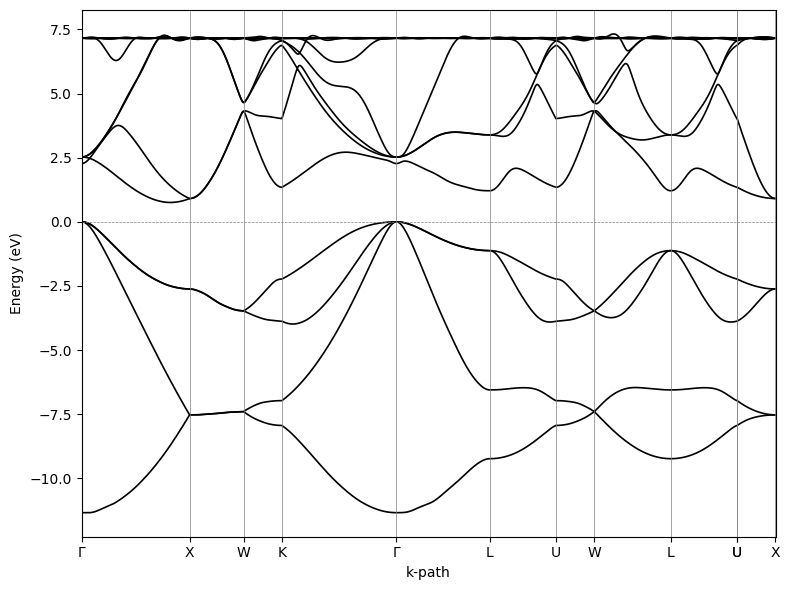

In [24]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

bands_file = Path(outputdir) / 'bands_0.dat'
kpath_file = Path(outputdir) / 'kpath_points.txt'

arr = np.loadtxt(bands_file)
k = arr[:, 0]
energies = arr[:, 1:]

labels = []
steps = []

with open(kpath_file) as f:
    for line in f:
        parts = line.split()
        if len(parts) != 2:
            break
        labels.append(parts[0].replace('gG', r'$\Gamma$'))
        steps.append(int(parts[1]))

# cumulative tick locations
tick_idx = np.cumsum([0] + steps[:-1])

# keep only valid tick positions
mask = tick_idx < len(k)
tick_idx = tick_idx[mask]
labels = np.array(labels)[mask]

tick_pos = k[tick_idx]

fig, ax = plt.subplots(figsize=(8, 6))

for i in range(energies.shape[1]):
    ax.plot(k, energies[:, i], 'k-', lw=1.2)

ax.axhline(0, color='gray', ls='--', lw=0.5)

for x in tick_pos:
    ax.axvline(x, color='gray', lw=0.5)

ax.set_xticks(tick_pos)
ax.set_xticklabels(labels)
ax.set_xlim(k[0], k[-1])

ax.set_xlabel('k-path')
ax.set_ylabel('Energy (eV)')

plt.tight_layout()
plt.show()

The silicon band structure displays the characteristic **indirect gap**: the valence band maximum sits at $\Gamma$ while the conduction band minimum lies between $\Gamma$ and $X$. PBE-GGA underestimates the gap (~0.6 eV calculated vs 1.1 eV experimental) — a well-known limitation of the approximate exchange-correlation functional. One can see the low projectability bands that have been excluded from the PAO Hamiltonian in the conduction band region above ~7.4 eV.

## 6. Interpolate the Brillouin-Zone Grid

`interpolated_hamiltonian()` doubles the k-grid density by Fourier interpolation (e.g. 12×12×12 → 24×24×24), providing a finer BZ sampling for accurate DOS and transport integrations.

`pao_eigh()` diagonalises $\tilde{H}(\mathbf{k})$ at every k-point on the interpolated grid, storing the eigenvalues and eigenvectors needed downstream.


In [9]:
paoflow.interpolated_hamiltonian()
paoflow.pao_eigh()

Performing Fourier interpolation on a larger grid.
d : nk -> nfft
1 : 12 -> 24
2 : 12 -> 24
3 : 12 -> 24
New estimated maximum array size: 0.86 GBytes
R -> k with Zero Padding in:               76.767 sec
Eigenvalues in:                             0.726 sec


## 7. Momentum Matrix Elements and Adaptive Smearing

`gradient_and_momenta()` computes the k-gradient of the Hamiltonian,

$$\nabla_{\mathbf{k}} H(\mathbf{k}) = i\sum_{\mathbf{R}} \mathbf{R}\,H(\mathbf{R})\,e^{i\mathbf{k}\cdot\mathbf{R}},$$

and from it the momentum matrix elements $\mathbf{p}_{nm}(\mathbf{k})$ and group velocities $\mathbf{v}_{n\mathbf{k}} = \hbar^{-1}\nabla_{\mathbf{k}}\varepsilon_{n\mathbf{k}}$ needed for transport.

`adaptive_smearing()` assigns each (band, k-point) a Gaussian broadening width proportional to $|\nabla_{\mathbf{k}}\varepsilon_{n\mathbf{k}}|$. Flat bands receive more broadening than dispersive ones, improving BZ integration accuracy without over-smearing sharp features.


In [10]:
paoflow.gradient_and_momenta()
paoflow.adaptive_smearing()

Gradient in:                                5.554 sec
Momenta in:                                 1.109 sec
Adaptive Smearing in:                       0.150 sec


## 8. Compute and Plot the Density of States

The electronic density of states,

$$g(\varepsilon) = \frac{1}{N_k}\sum_{n,\mathbf{k}}\delta(\varepsilon - \varepsilon_{n\mathbf{k}}),$$

is evaluated with adaptive Gaussian broadening at 1000 energy points spanning the full valence band and the lower conduction edge.

The silicon DOS shows a clear gap separating the valence and conduction manifolds. Van Hove singularities at band edges appear as steps or peaks. The total integrated weight under the valence DOS equals the number of valence electrons per cell (8 for Si).

**Output:** 

`dosdk_0.dat` - contains the DOS as a function of energy

`*_pdosdk_*.dat` - contains the projected DOS onto each PAO as a function of energy. The postfix indicates the spin channel (0 for non-spin-polarised calculations). The prefix indicates the PAO index (e.g. `0` for the first PAO, `1` for the second, etc.).


In [11]:
paoflow.dos(emin=-12.0, emax=2.2, ne=1000)

Writing Adaptive DoS Files
DoS (Adaptive Smearing) in:                15.784 sec


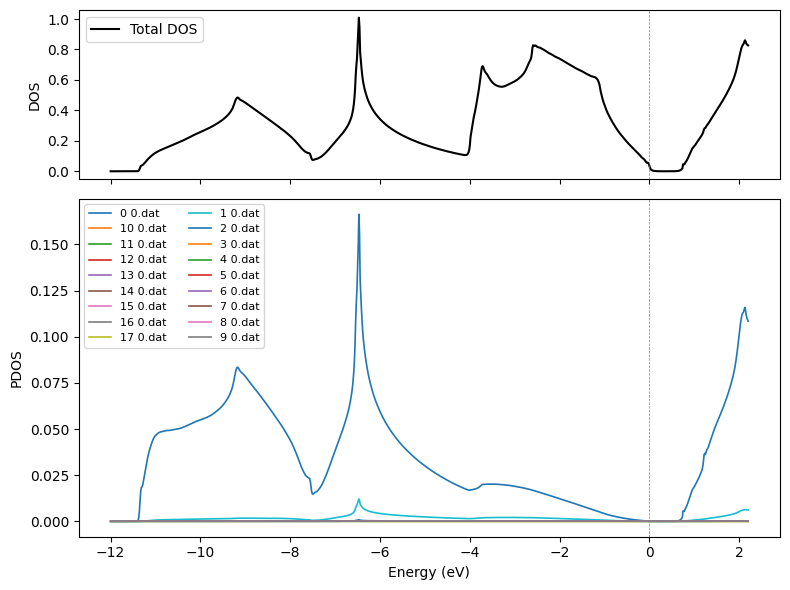

In [28]:
# ----- total DOS -----
dos_file = Path(outputdir) / 'dosdk_0.dat'
dos_data = np.loadtxt(dos_file)

# ----- PDOS files -----
pdos_files = sorted(Path(outputdir).glob('*_pdosdk_*'))

fig, (ax_dos, ax_pdos) = plt.subplots(
    2, 1, figsize=(8, 6), sharex=True, gridspec_kw={'height_ratios': [1, 2]}
)

# Total DOS
ax_dos.plot(dos_data[:, 0], dos_data[:, 1], lw=1.5, color='k', label='Total DOS')
ax_dos.axvline(0, color='gray', ls='--', lw=0.5)
ax_dos.set_ylabel('DOS')
ax_dos.legend()

# PDOS
for f in pdos_files:
    data = np.loadtxt(f)

    label = f.name.replace('_pdosdk_', ' ')
    ax_pdos.plot(data[:, 0], data[:, 1], lw=1.2, label=label)

ax_pdos.axvline(0, color='gray', ls='--', lw=0.5)
ax_pdos.set_xlabel('Energy (eV)')
ax_pdos.set_ylabel('PDOS')
ax_pdos.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.show()

## 9. Compute and Plot Transport Tensors

Within the Boltzmann transport framework and the constant relaxation-time approximation, the electrical conductivity tensor is

$$\sigma_{\mu\nu}(E) = e^2\tau\,\frac{1}{N_k}\sum_{n,\mathbf{k}} v^\mu_{n\mathbf{k}}\,v^\nu_{n\mathbf{k}} \left(-\frac{\partial f}{\partial\varepsilon}\right)_{\varepsilon_{n\mathbf{k}}},$$

where $\tau$ is the (assumed constant) relaxation time and $f$ is the Fermi–Dirac distribution. PAOFLOW also computes the Seebeck coefficient and electronic thermal conductivity from energy-weighted moments of the same expression. All tensors are functions of chemical potential.

**Output:** `sigmagauss_0.dat`, `Seebeckgauss_0.dat`, `kappagauss_0.dat`, `PFgauss_0.dat`


In [13]:
paoflow.transport(emin=-12.0, emax=2.2)
paoflow.finish_execution()

Transport in:                              12.893 sec
Total CPU time =                          149.601 sec
Memory usage on rank 0:  1.0999 GB
Maximum concurrent memory usage:  1.0999 GB


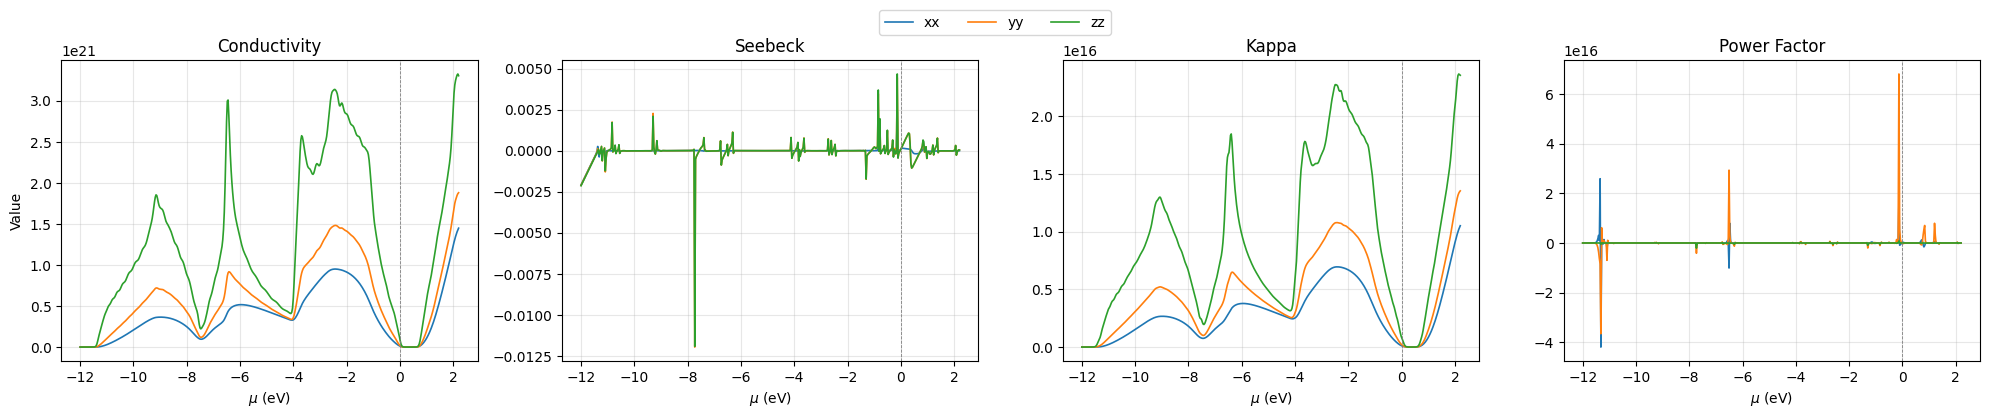

In [ ]:
# Files
sigma_file = Path(outputdir) / 'sigmagauss_0.dat'
seebeck_file = Path(outputdir) / 'Seebeckgauss_0.dat'
kappa_file = Path(outputdir) / 'kappagauss_0.dat'
pf_file = Path(outputdir) / 'PFgauss_0.dat'

# Load data
sigma_data = np.loadtxt(sigma_file)
seebeck_data = np.loadtxt(seebeck_file)
kappa_data = np.loadtxt(kappa_file)
pf_data = np.loadtxt(pf_file)

datasets = [
    ('Conductivity', sigma_data),
    ('Seebeck', seebeck_data),
    ('Kappa', kappa_data),
    ('Power Factor', pf_data),
]

tensor_labels = ['xx', 'yy', 'zz']

fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True)

for ax, (title, data) in zip(axes, datasets):
    if data.ndim == 1:
        data = data.reshape(1, -1)

    mu = data[:, 1]  # chemical potential

    for i, label in enumerate(tensor_labels):
        ax.plot(mu, data[:, i + 2], lw=1.2, label=label)

    ax.axvline(0.0, color='gray', ls='--', lw=0.6)
    ax.set_title(title)
    ax.set_xlabel(r'$\mu$ (eV)')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('Value')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=len(labels), bbox_to_anchor=(0.5, 1.05))

plt.tight_layout()
plt.show()

## 10. Further Reading